In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Accuracy test

In [71]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import itertools
import sys 
sys.path.append('/home/lhasbini/como_school/como_project4/src/')
from text_processing_functions import *
from constants import *
import LLM_functions
from plot_functions import *
from post_process_functions import *
from accuracy import *
from data import *
from geocoding import *
import copy as cp
import ast

#Package for accuracy 
from sklearn.metrics.pairwise import cosine_similarity

#For plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import cartopy.io.shapereader as shpreader
from cartopy.io import shapereader

In [164]:
# reports_chat = pd.read_csv(DATA_OUT_LLMS+"labelled_reports_response_llm_levels_haz_types_subtypes_impacts.csv", index_col=0)
reports_chat = pd.read_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv')

reports_labelled_laura = pd.read_csv(DATA_LABELLED+"labelled_example_haz-subtype-emdat_chat-format_geocoding_laura.csv")
reports_labelled_luca = pd.read_csv(DATA_LABELLED+"labelled_example_haz-subtype-emdat_chat-format_geocoding_luca.csv", index_col=0)
reports_labelled = pd.concat([reports_labelled_laura, reports_labelled_luca], axis=0)

In [165]:
#Filter labelling on available output of chat
reports_labelled = reports_labelled.loc[reports_labelled.appealCode.isin(reports_chat.appealCode.unique())]

In [147]:
# reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(separate_locs))
# reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(remove_startspace))
# reports_chat['region'] = reports_chat.apply(lambda row: [item for item in (row['region'] or []) + (row['state'] or []) if item is not None], axis=1)
# reports_chat = reports_chat.drop('state', axis=1)

In [148]:
# reports_chat = clean_chat_format(reports_chat)
# reports_chat_geo = geocoding_labelled_reports(reports_chat)

No results for query:  Naushahro Feroz, Pakistan Try country only
No results for query:  Naushahro Feroz, Pakistan Try country only
No results for query:  Naushahro Feroz, Pakistan Try country only
No results for query:  Naushahro Feroz, Pakistan Try country only
No results for query:  Naushahro Feroz, Pakistan Try country only
No results for query:  Naushahro Feroz, Pakistan Try country only
No results for query:  Mackary, Cameroon Try country only
No results for query:  Balakozo, Nigeria Try country only
No results for query:  Talata Mafara town, Nigeria Try country only
No results for query:  southern provinces, Rwanda Try country only
No results for query:  southern and central Mozambique, Mozambique Try country only
No results for query:  Central and Southern regions, Laos Try country only
No results for query:  Xaixomboun, Laos Try country only
No results for query:  southeastern Brazil, Brazil Try country only
No results for query:  southeastern Brazil, Brazil Try country only
N

In [149]:
# reports_chat_geo.to_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv', encoding='utf-8', index=False)

# Look for event-centroid

In [112]:
dict_color = {"Flood" : "blue", "Storm" : "purple", "Mass movement" : "brown", "Wave action": "pink"}
dict_marker = {
    "Flood": "o",         # Circle
    "Earthquake": "s",    # Square
    "Mass movement": "^",     # Triangle
    "Storm": "*",         # Diamond
    "Drought": "p",       # Pentagon
    "Wildfire": "v",      # Star
    "Wave action": "h"
}

In [16]:
def centeroidnp(arr):
    length = arr.shape[0]
    sum_x = np.sum(arr[:, 0])
    sum_y = np.sum(arr[:, 1])
    return sum_x/length, sum_y/length

In [90]:
appealCode_test = "MDRDZ011"
tmp_labelled = reports_labelled_laura.loc[reports_labelled_laura.appealCode == appealCode_test]
tmp_chat = reports_chat_geo.loc[reports_chat_geo.appealCode == appealCode_test]

In [91]:
grouping_columns = ["hazardType", "hazardSubtypes", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"] 

#Labelled reports
tmp_labelled[grouping_columns] = tmp_labelled[grouping_columns].fillna('missing')
tmp_labelled_event = tmp_labelled.groupby(grouping_columns)

#Output from chat
tmp_chat[grouping_columns] = tmp_chat[grouping_columns].fillna('missing')
tmp_chat_event = tmp_chat.groupby(grouping_columns)

/tmp/ipykernel_224438/486962333.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_labelled[grouping_columns] = tmp_labelled[grouping_columns].fillna('missing')
/tmp/ipykernel_224438/486962333.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_chat[grouping_columns] = tmp_chat[grouping_columns].fillna('missing')


In [93]:
#Events found from the labelling
for haz in tmp_labelled_event.groups.keys() : 
    print(haz)
#Events found from chat
for haz in tmp_chat_event.groups.keys() : 
    print(haz)

('Flood', 'missing', 'Algeria', 2024.0, 9.0, 5.0, 2024.0, 9.0, 8.0)
('Flood', 'missing', 'Algeria', 2024, 9.0, 5.0, 2024, 9.0, 8.0)
('Storm', 'tropical storm', 'Algeria', 2024, 9.0, 5.0, 2024, 9.0, 8.0)


/tmp/ipykernel_224438/3558643876.py:13: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


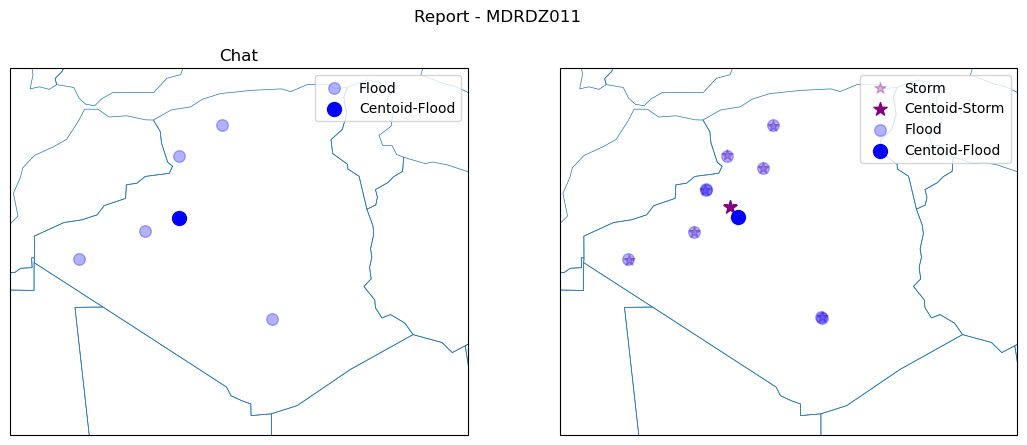

In [103]:
#Plot of the results of labelling 
# keys_labelled = tmp_labelled_event.groups.keys()
# for i in keys_labelled:
#     labelled_event_loop = tmp_labelled_event.get_group(i) 
#     coordinates_labelled = np.column_stack((labelled_event_loop["longitude"], labelled_event_loop["latitude"]))
#     centroid_labelled = centeroidnp(coordinates_labelled)
#     print(centroid_labelled)
import geopandas as gpd
def add_jitter(coords, scale=0.05):
    return coords + np.random.uniform(-scale, scale, size=coords.shape)

f, axes = plt.subplots(1, 2, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(13, 5))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.boundary.plot(ax=axes[0], linewidth=0.5)
world.boundary.plot(ax=axes[1], linewidth=0.5)
keys_labelled = tmp_labelled_event.groups.keys()
for i in keys_labelled : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    labelled_event_loop = tmp_labelled_event.get_group(i) 
    coordinates_labelled = np.column_stack((labelled_event_loop["longitude"], labelled_event_loop["latitude"]))
    centroid_labelled = centeroidnp(coordinates_labelled)
    
    coordinates_gpd = gpd.GeoDataFrame(labelled_event_loop, geometry=gpd.points_from_xy(labelled_event_loop.longitude, labelled_event_loop.latitude))
    x_values = add_jitter(coordinates_gpd.geometry.x)
    y_values = add_jitter(coordinates_gpd.geometry.y)

    hazard = labelled_event_loop["hazardType"].iloc[0]
    axes[0].scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3, label=hazard
    )
    
    axes[0].scatter(
            centroid_labelled[0], centroid_labelled[1], 
            color=dict_color[hazard], 
            marker=marker, 
            s=100, alpha=1, label="Centoid-"+hazard
        )
axes[0].set_title("Labelling")

#For result with chat
keys_chat = tmp_chat_event.groups.keys()
for i in keys_chat : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    hazard = chat_event_loop["hazardType"].iloc[0]
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    chat_event_loop = tmp_chat_event.get_group(i) 
    coordinates_chat = np.column_stack((chat_event_loop["longitude"], chat_event_loop["latitude"]))
    centroid_chat = centeroidnp(coordinates_chat)
    
    coordinates_gpd = gpd.GeoDataFrame(chat_event_loop, geometry=gpd.points_from_xy(chat_event_loop.longitude, chat_event_loop.latitude))
    x_values = add_jitter(coordinates_gpd.geometry.x)
    y_values = add_jitter(coordinates_gpd.geometry.y)

    axes[1].scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3, label=hazard
    )
    
    axes[1].scatter(
            centroid_chat[0], centroid_chat[1], 
            color=dict_color[hazard], 
            marker=marker, 
            s=100, alpha=1, label="Centoid-"+hazard
        )
axes[0].set_title("Chat")

# Set the focus on Uganda
for ax in axes : 
    ax.set_xlim([-10, 15])  # Longitude limits
    ax.set_ylim([18, 38])  # Latitude limits
    ax.legend(fontsize=10)
plt.suptitle("Report - "+appealCode_test)
plt.show()

In [106]:
appealCode_test = "MDR55001"
tmp_labelled = reports_labelled_laura.loc[reports_labelled_laura.appealCode == appealCode_test]
tmp_chat = reports_chat_geo.loc[reports_chat_geo.appealCode == appealCode_test]

grouping_columns = ["hazardType", "hazardSubtypes", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"] 

#Labelled reports
tmp_labelled[grouping_columns] = tmp_labelled[grouping_columns].fillna('missing')
tmp_labelled_event = tmp_labelled.groupby(grouping_columns)

#Output from chat
tmp_chat[grouping_columns] = tmp_chat[grouping_columns].fillna('missing')
tmp_chat_event = tmp_chat.groupby(grouping_columns)

/tmp/ipykernel_224438/1985289930.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_labelled[grouping_columns] = tmp_labelled[grouping_columns].fillna('missing')
/tmp/ipykernel_224438/1985289930.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_chat[grouping_columns] = tmp_chat[grouping_columns].fillna('missing')


/tmp/ipykernel_224438/3468070968.py:13: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


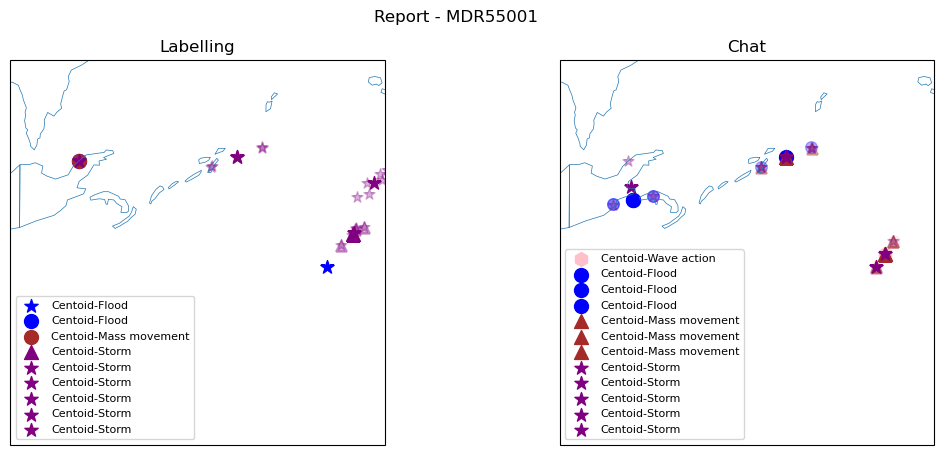

In [123]:
#Plot of the results of labelling 
# keys_labelled = tmp_labelled_event.groups.keys()
# for i in keys_labelled:
#     labelled_event_loop = tmp_labelled_event.get_group(i) 
#     coordinates_labelled = np.column_stack((labelled_event_loop["longitude"], labelled_event_loop["latitude"]))
#     centroid_labelled = centeroidnp(coordinates_labelled)
#     print(centroid_labelled)
import geopandas as gpd
def add_jitter(coords, scale=0.05):
    return coords + np.random.uniform(-scale, scale, size=coords.shape)

f, axes = plt.subplots(1, 2, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(13, 5))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.boundary.plot(ax=axes[0], linewidth=0.5)
world.boundary.plot(ax=axes[1], linewidth=0.5)
keys_labelled = tmp_labelled_event.groups.keys()
for i in keys_labelled : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    labelled_event_loop = tmp_labelled_event.get_group(i) 
    coordinates_labelled = np.column_stack((labelled_event_loop["longitude"], labelled_event_loop["latitude"]))
    centroid_labelled = centeroidnp(coordinates_labelled)
    
    coordinates_gpd = gpd.GeoDataFrame(labelled_event_loop, geometry=gpd.points_from_xy(labelled_event_loop.longitude, labelled_event_loop.latitude))
    x_values = add_jitter(coordinates_gpd.geometry.x)
    y_values = add_jitter(coordinates_gpd.geometry.y)

    hazard = labelled_event_loop["hazardType"].iloc[0]
    axes[0].scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3#, label=hazard
    )
    
    axes[0].scatter(
            centroid_labelled[0], centroid_labelled[1], 
            color=dict_color[hazard], 
            marker=marker, 
            s=100, alpha=1, label="Centoid-"+hazard
        )
axes[0].set_title("Labelling")

#For result with chat
keys_chat = tmp_chat_event.groups.keys()
for i in keys_chat : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    hazard = chat_event_loop["hazardType"].iloc[0]
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    chat_event_loop = tmp_chat_event.get_group(i) 
    coordinates_chat = np.column_stack((chat_event_loop["longitude"], chat_event_loop["latitude"]))
    centroid_chat = centeroidnp(coordinates_chat)
    
    coordinates_gpd = gpd.GeoDataFrame(chat_event_loop, geometry=gpd.points_from_xy(chat_event_loop.longitude, chat_event_loop.latitude))
    x_values = add_jitter(coordinates_gpd.geometry.x)
    y_values = add_jitter(coordinates_gpd.geometry.y)

    axes[1].scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3#, label=hazard
    )
    
    axes[1].scatter(
            centroid_chat[0], centroid_chat[1], 
            color=dict_color[hazard], 
            marker=marker, 
            s=100, alpha=1, label="Centoid-"+hazard
        )
axes[1].set_title("Chat")

# Set the focus on Uganda
for ax in axes : 
    ax.set_xlim([140, 179])  # Longitude limits
    ax.set_ylim([20, -20])  # Latitude limits
    ax.legend(fontsize=8, loc='lower left')
plt.suptitle("Report - "+appealCode_test)
plt.show()

# Compute accuracy

In [166]:
accuracy_columns = ["hazardType", "hazardSubtypes", "country", "region", "city", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay", "hazardName"]
accuracy = calculate_precision_per_report(reports_chat, reports_labelled, accuracy_columns)

In [167]:
accuracy

,hazardType,hazardSubtypes,country,region,city,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName
0,0.799376,0.576624,0.857214,0.921893,1.036391,0.934783,0.793478,0.695652,0.934783,1.043478,0.978261,0.960145


In [168]:
accuracy_per_hazard = calculate_precision_per_hazardType(reports_chat, reports_labelled, accuracy_columns)

In [217]:
df_list = []

for key, df in accuracy_per_hazard.items():
    # Add a new column 'HAZARD' with the key value
    df['HAZARD'] = key
    # Append the dataframe to the list
    df_list.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

In [218]:
combined_df

,hazardType,hazardSubtypes,country,region,city,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,HAZARD
0,0.750000,0.750000,0.500000,1.333333,1.111111,1.0,0.666667,0.000000,1.000000,0.333333,0.0,1.000000,Drought
1,1.000000,0.707107,1.000000,0.636364,0.045455,0.5,0.500000,0.500000,1.000000,1.000000,1.0,1.000000,Wildfire
2,1.000000,1.000000,1.000000,0.625000,1.000000,1.0,0.500000,0.333333,1.000000,2.000000,2.0,1.000000,Earthquake
3,0.500000,0.441421,0.457735,3.800000,3.450000,1.0,1.200000,1.200000,1.000000,1.200000,1.2,1.000000,Mass movement
4,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Volcanic activity
5,1.000000,0.447140,0.921100,1.165788,1.128047,1.0,0.966667,0.900000,0.966667,0.966667,0.9,1.000000,Flood
6,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wave action
7,0.500000,0.176777,0.500000,2.500000,4.562500,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,Extreme temperature
8,0.555556,0.444444,0.508126,0.888039,2.925000,0.9,0.800000,0.600000,1.000000,1.000000,0.8,0.616667,Storm


In [227]:
#Compute the number of event for hazardType
#One event is a unique combinaison of variables
#["appealCode", "hazardType", "hazardSubtypes", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"] 
unique_event_columns = ["appealCode", "hazardType", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]
count_event_labelled = {}
count_event_chat = {}

reports_labelled_event = reports_labelled.groupby(unique_event_columns)
count_event_labelled["All"] = len(reports_labelled_event.groups.keys())
reports_chat_event = reports_chat.groupby(unique_event_columns)
count_event_chat["All"] = len(reports_chat_event.groups.keys())

#Loop per event
for hazard in maintype_to_subytpe_emdat.keys() :
    reports_labelled_haz = reports_labelled.loc[reports_labelled.hazardType == hazard].groupby(unique_event_columns)
    count_event_labelled[hazard] = len(reports_labelled_haz.groups.keys())
    
    reports_chat_haz = reports_chat.loc[reports_chat.hazardType == hazard].groupby(unique_event_columns)
    count_event_chat[hazard] = len(reports_chat_haz.groups.keys())

for subhazard in ast.literal_eval(hazard_all_subtype_emdat) :
    reports_labelled_haz = reports_labelled.loc[reports_labelled.hazardSubtypes == subhazard].groupby(unique_event_columns)
    count_event_labelled[subhazard] = len(reports_labelled_haz.groups.keys())
    
    reports_chat_haz = reports_chat.loc[reports_chat.hazardSubtypes == subhazard].groupby(unique_event_columns)
    count_event_chat[subhazard] = len(reports_chat_haz.groups.keys())

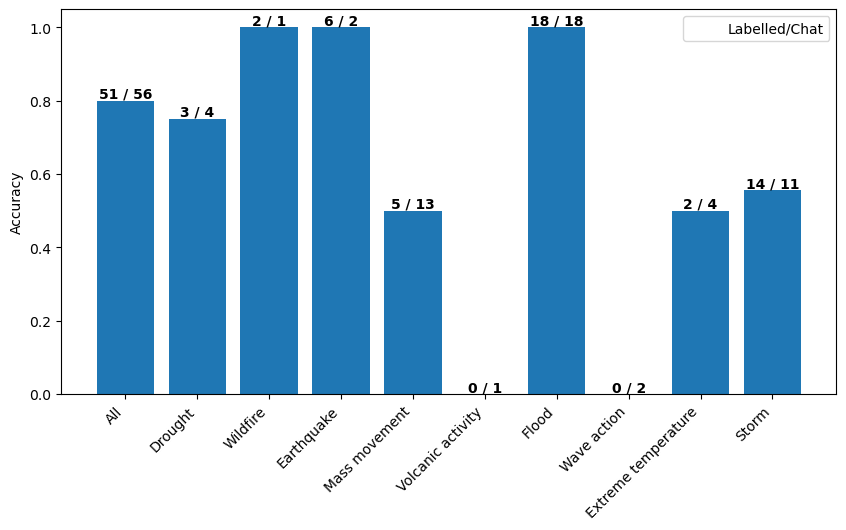

In [228]:
x_ticks = ["All"] + combined_df["HAZARD"].to_list()
y_values = [float(accuracy.hazardType)]+combined_df.hazardType.to_list()

plt.figure(figsize=(10, 5))  # Adjust figure size if needed
bars = plt.bar(x_ticks, y_values)

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")  # Rotate by 45° and align to the right

# Add values above each bar with two-colored text
for i, bar in enumerate(bars):
    height = bar.get_height()
    
    # Get count values for the current x_tick
    count_labelled = count_event_labelled[x_ticks[i]]
    count_chat = count_event_chat[x_ticks[i]]
    
    # Combine both numbers into a single string with different colors
    text = f"{count_labelled} / {count_chat}"
    
    # Add the text at the top of the bars
    plt.text(bar.get_x() + bar.get_width()/2, height, text,
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add legend for colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='w',label='Labelled/Chat'),
]
plt.legend(handles=legend_elements, fontsize=10, loc="upper right")

plt.ylabel("Accuracy")
plt.show()

In [206]:
accuracy_per_hazardSubtype = calculate_precision_per_hazardSubtypes(reports_chat, reports_labelled, accuracy_columns)
df_list = []

for key, df in accuracy_per_hazardSubtype.items():
    # Add a new column 'HAZARD' with the key value
    df['HAZARD'] = key
    # Append the dataframe to the list
    df_list.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
combined_df_Subtypes = pd.concat(df_list, ignore_index=True)

In [207]:
# combined_df_Subtypes

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

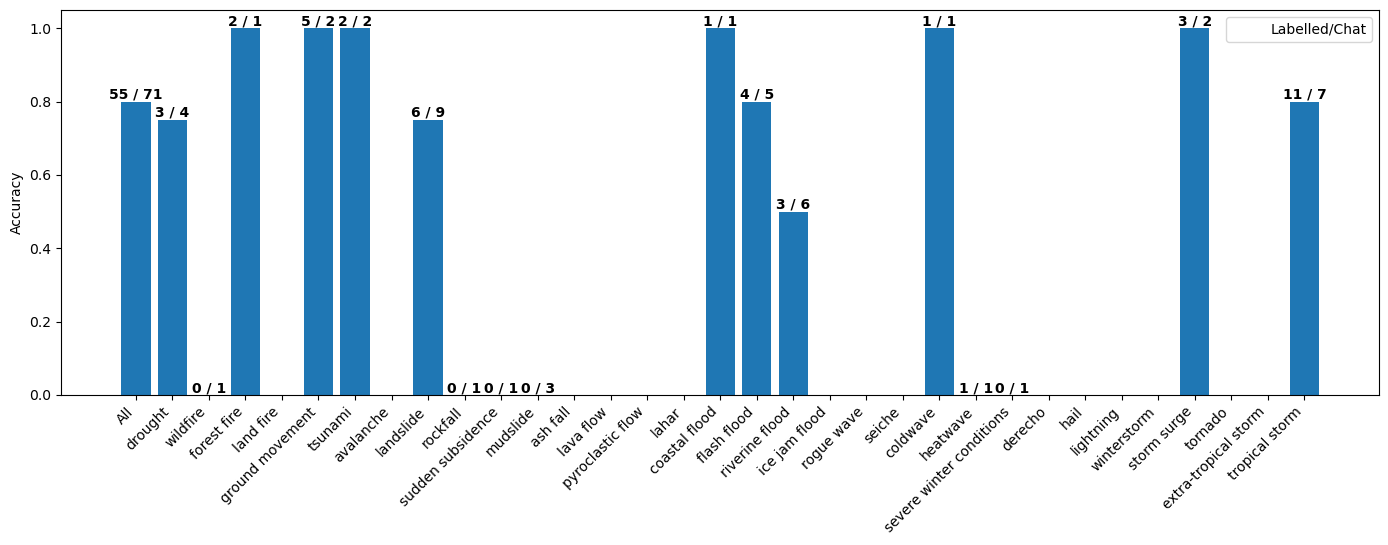

In [225]:
x_ticks = ["All"] + combined_df_Subtypes["HAZARD"].to_list()
y_values = [float(accuracy.hazardType)]+combined_df_Subtypes.hazardSubtypes.to_list()

plt.figure(figsize=(17, 5))  # Adjust figure size if needed
bars = plt.bar(x_ticks, y_values)

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")  # Rotate by 45° and align to the right

# Add values above each bar with two-colored text
for i, bar in enumerate(bars):
    height = bar.get_height()
    
    # Get count values for the current x_tick
    count_labelled = count_event_labelled[x_ticks[i]]
    count_chat = count_event_chat[x_ticks[i]]
    
    # Combine both numbers into a single string with different colors
    text = f"{count_labelled} / {count_chat}"
    
    # Add the text at the top of the bars
    plt.text(bar.get_x() + bar.get_width()/2, height, text,
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add legend for colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='w',label='Labelled/Chat'),
]
plt.legend(handles=legend_elements, fontsize=10, loc="upper right")

plt.ylabel("Accuracy")
plt.show()

In [4]:
path_test_csv = '/scratchx/lhasbini/como_school/'

######   Predicted with hazard detected by regex
#labelled_chat_output = pd.read_csv(path_test_csv+'11_label_v2_predict_llmgpt-4o-mini.csv')
#labelled_chat_output = pd.read_csv(path_test_csv+'10labelled_response_llm_levels_1.csv')
labelled_regex_output = pd.read_csv(path_test_csv+'10labelled_response_llm_levels_subtypes_1.csv')
# labelled_chat_output = labelled_chat_output.loc[:,['Hazard', 'Country', 'Location', 'Start_Date', 'End_Date', 'appealCode']]
# labelled_chat_output = labelled_chat_output.dropna(subset=['Hazard']).copy()

# #Convert country code 
# labelled_chat_output['Country'] = labelled_chat_output['Country'].str.extract(r"\['(.*?)'\]")
# labelled_chat_output['Country'] = [country_name_to_iso3(cntr) for cntr in labelled_chat_output['Country']]

###### Predicted with hazard detected by CHAT
labelled_chat_output = pd.read_csv(path_test_csv+'10labelled_response_llm_levels_haz_types_subtypes_1.csv')

#####    Labelled
labelled_example = pd.read_csv(path_test_csv+'labelled_example_haz-subtype-emdat.csv')
labelled_example = labelled_example.rename(columns={'Locations': 'Location'})

In [5]:
#Add the em-dat main type 
# labelled_chat_output['Hazard_main'] = labbelled_chat_output['Hazard'].map(hazard_category_map)
labelled_example = labelled_example.rename(columns={"Hazard" : "Hazard_subtype"})
labelled_example['Hazard'] = labelled_example['Hazard_subtype'].map(hazard_category_map)

# Accuracy

In [6]:
unique_countries_ISO = [country.alpha_3 for country in pycountry.countries]
unique_dict = {
    'Hazard' : list(hazard_subtype_emdat), 
    'Hazard_subtype' : list(hazard_all_subtype_emdat), 
    'Country' : unique_countries_ISO
}

In [7]:
## PROCESS THE FILES TO COMPUTE ACCURACY 
labelled_regex_output_acc                   = labelled_regex_output[["hazardType", "country_iso3", "appealCode", "hazardSubtypes"]]
labelled_regex_output_acc                   = labelled_regex_output_acc.rename(columns={'hazardType': 'Hazard', "country_iso3" : "Country", "hazardSubtypes" : "Hazard_subtype"})
labelled_regex_output_acc['Hazard_subtype'] = labelled_regex_output_acc['Hazard_subtype'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

labelled_chat_output_acc                   = labelled_chat_output[["hazardType", "country_iso3", "appealCode", "hazardSubtypes"]]
labelled_chat_output_acc                   = labelled_chat_output_acc.rename(columns={'hazardType': 'Hazard', "country_iso3" : "Country", "hazardSubtypes" : "Hazard_subtype"})
labelled_chat_output_acc['Hazard_subtype'] = labelled_chat_output_acc['Hazard_subtype'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [9]:
columns_accuracy = ['Hazard', "Hazard_subtype", 'Country']#['Hazard_Type', 'Hazard_Count', 'Country']
precision_regex = LLM_functions.calculate_precision_v2(labelled_regex_output_acc, labelled_example, columns_accuracy, unique_dict = unique_dict)
precision_chat = LLM_functions.calculate_precision_v2(labelled_chat_output_acc, labelled_example, columns_accuracy, unique_dict = unique_dict)

In [20]:
labelled_chat_output_acc.appealCode.unique()

array(['MDRDZ011', 'MDRPK026', 'MDRCM039', 'MDRBJ019', 'MDRSD034',
       'MDRNG041', 'MDRRW022', 'MDRZM022', 'MDRUG050', 'MDRMZ024'],
      dtype=object)

In [19]:
labelled_regex_output_acc.appealCode.unique()

array(['MDRPK026', 'MDRSD034', 'MDRRW022', 'MDRZM022', 'MDRUG050',
       'MDRMZ024'], dtype=object)

In [23]:
appealmissed = ["MDRDZ011", "MDRCM039", "MDRBJ019", "MDRNG041"]
labelled_chat_output_acc.loc[labelled_chat_output_acc.appealCode.isin(appealmissed)]

,Hazard,Country,appealCode,Hazard_subtype
0,Flood,DZA,MDRDZ011,[]
1,Storm,DZA,MDRDZ011,[tropical storm]
14,Flood,CMR,MDRCM039,[riverine flood]
15,Flood,BEN,MDRBJ019,[riverine flood]
26,Flood,NGA,MDRNG041,[]
27,Flood,NGA,MDRNG041,[riverine flood]
28,Flood,NGA,MDRNG041,[]


In [12]:
precision_regex

,Hazard,Hazard_subtype,Country
0,0.683492,0.726265,1.0


In [11]:
precision_chat

,Hazard,Hazard_subtype,Country
0,0.825431,0.568005,1.0


# Plots 

In [123]:
df_output = df_cleaned.copy()

# Look for reports with MultiHazards 

# Count hazards per appealCode
hazard_counts = df_output['appealCode'].value_counts().reset_index()
hazard_counts.columns = ['appealCode', 'Hazard_Count']

# Add a new column to indicate if there are multiple hazards
df_output = df_output.merge(hazard_counts, on='appealCode')
df_output['Multi_Hazards'] = df_output['Hazard_Count'] > 1

# Drop the Hazard_Count column if no longer needed
df_output.drop(columns=['Hazard_Count'], inplace=True)

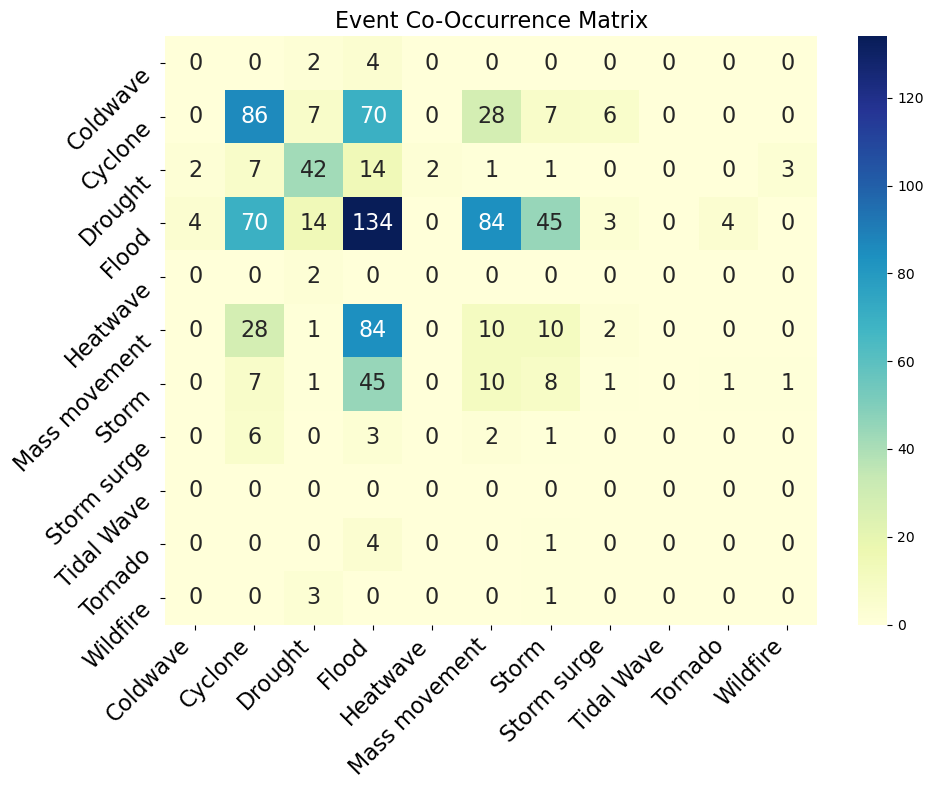

In [129]:
fig = matrix_co_occurence(df_output, sorted(unique_hazards))

In [133]:
#Map number of compound in each countries
unique_countries_haz = np.unique(df_output['Country']).tolist()
nb_compound_country = {country: 0 for country in unique_countries_haz}

#dict(unique_countries_haz)
for appeal in df_output.appealCode.unique() : 
    report = df_output.loc[df_output.appealCode == appeal]
    #Check if more than one hazard are identified
    if len(report)>1 : 
        unique_countires_rep = np.unique(report['Country'].tolist())
        for country in unique_countires_rep : 
            nb_compound_country[country]+=1

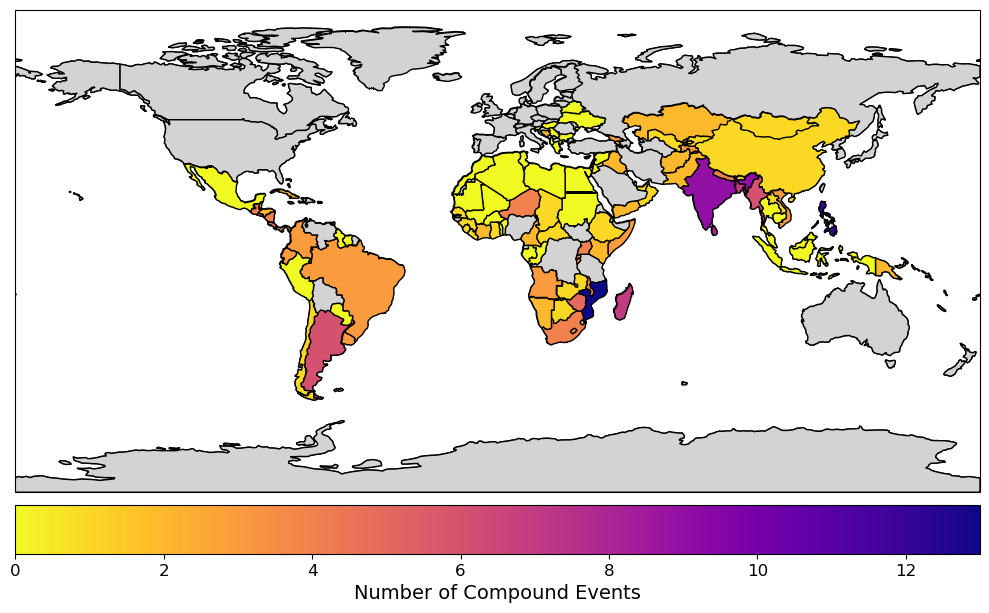

In [157]:
map_nb_compound = map_nb_compounds(nb_compound_country,  
                                   colormap = 'plasma_r', vmax = max(nb_compound_country.values()), cbar_title='Number of Compound Events',
                                   save=False)

In [158]:
hazard_counts = df_output.groupby(['Country', 'Hazard']).size().unstack(fill_value=0)

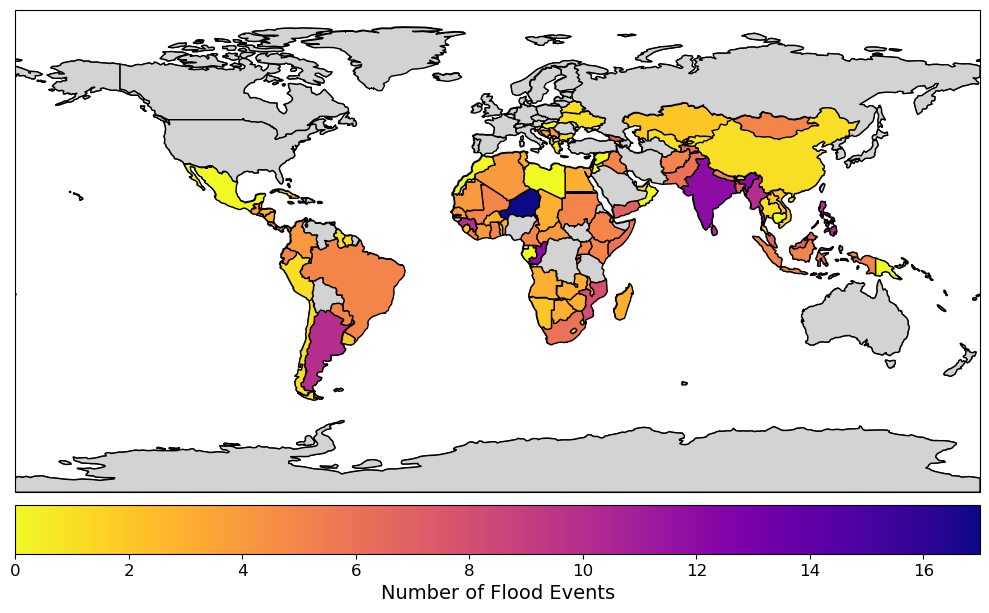

In [164]:
hazard_test = 'Flood'
map_nb_compound = map_nb_compounds(hazard_counts[hazard_test],  
                                   colormap = 'plasma_r', vmax = max(hazard_counts[hazard_test]), cbar_title='Number of Flood Events',
                                   save=False)

In [165]:
#Total number of compounded hazard in each country 
df_mh = df_output.loc[df_output.Multi_Hazards == True]
hazard_counts_mh = df_mh.groupby(['Country', 'Hazard']).size().unstack(fill_value=0)

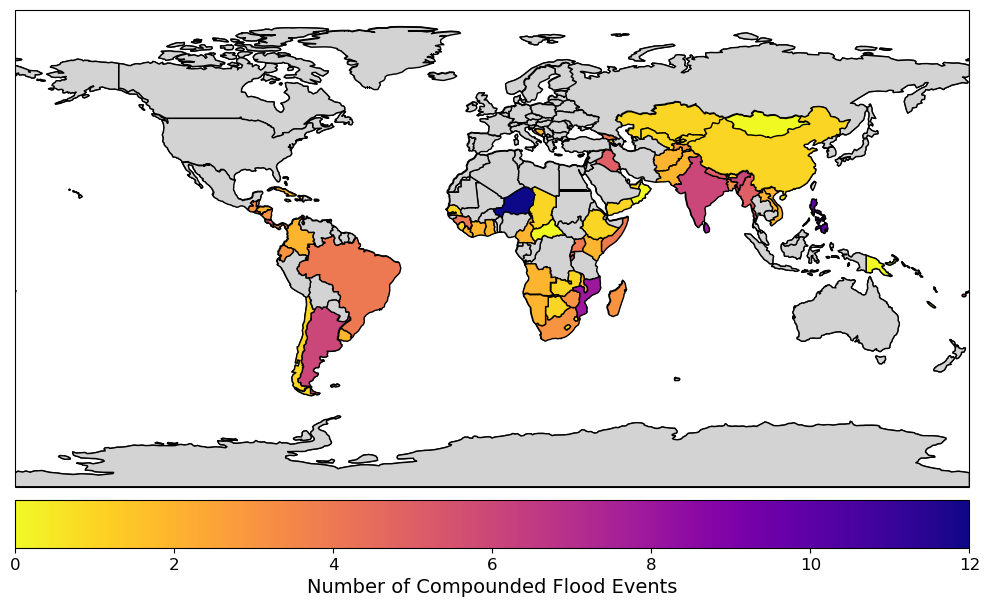

In [166]:
hazard_test = 'Flood'
map_nb_compound = map_nb_compounds(hazard_counts_mh[hazard_test],  
                                   colormap = 'plasma_r', vmax = max(hazard_counts_mh[hazard_test]), cbar_title='Number of Compounded Flood Events',
                                   save=False)

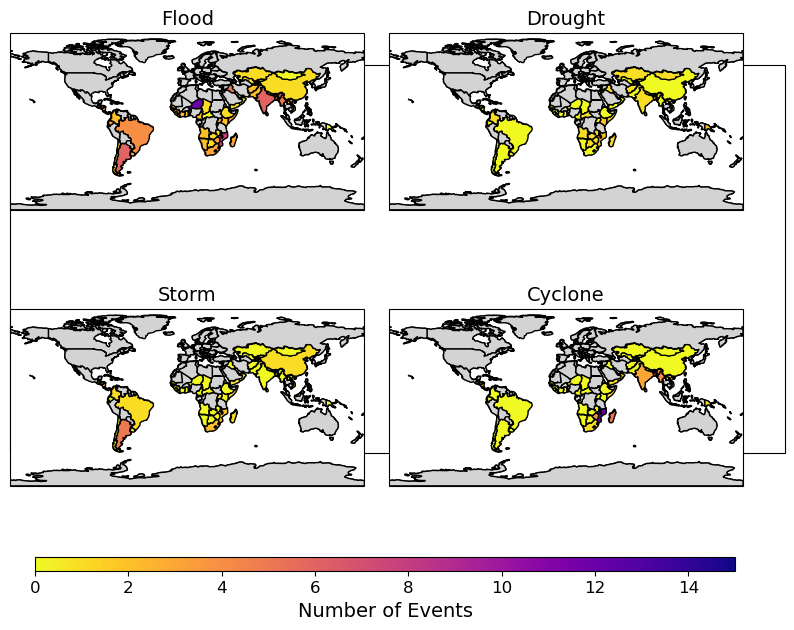

In [214]:
haz_plot = ['Flood', 'Drought', 'Storm', 'Cyclone']
map_multi_hazards = map_nb_hazards(hazard_counts_mh, haz_plot, vmax=15, cbar_title='Number of Events')

In [198]:
#Map number of compound in each countries
unique_countries_haz = np.unique(df_mh['Country']).tolist()
nb_compound_country = {country: 0 for country in unique_countries_haz}

#dict(unique_countries_haz)
for appeal in np.unique(df_mh.appealCode) : 
    report = df_mh.loc[df_mh.appealCode == appeal]
    #Check if more than one hazard are identified
    unique_countires_rep = np.unique(report['Country'].tolist())
    for country in unique_countires_rep : 
        nb_compound_country[country]+=1